IMPORT THE DATASET

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Economic_Long_Format_CORRECTED.csv")

print("Shape:", df.shape)

Shape: (368865, 7)


Perform Exploratory Data Analysis (EDA)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 368865 entries, 0 to 368864
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   country      368865 non-null  object 
 1   series_code  368865 non-null  object 
 2   indicator    368865 non-null  object 
 3   scale        368865 non-null  object 
 4   unit         368865 non-null  object 
 5   Year         368865 non-null  int64  
 6   Value        368865 non-null  float64
dtypes: float64(1), int64(1), object(5)
memory usage: 19.7+ MB


In [ ]:
print(df.dtypes)

country         object
series_code     object
indicator       object
scale           object
unit            object
Year             int64
Value          float64
dtype: object


In [ ]:
missing = df.isnull().sum()

missing[missing > 0]

,0


In [ ]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent[missing_percent > 0]

,0


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
df = df.drop_duplicates()

In [ ]:
df.describe()

,Year,Value
count,368865.000000,3.688650e+05
mean,2003.000000,4.002804e+10
std,12.987191,1.494067e+13
min,1981.000000,-1.789510e+07
25%,1992.000000,2.774000e+00
50%,2003.000000,1.383100e+01
75%,2014.000000,8.722900e+01
max,2025.000000,8.519540e+15


In [ ]:
print(df["country"].nunique())
df["country"].unique()

210


array(['United Kingdom', 'Italy', 'Liechtenstein, Principality of',
       'Malta', 'United States', 'Latin America and the Caribbean (LAC)',
       'Honduras', 'G7', 'Advanced Economies', 'Taiwan Province of China',
       'India', 'Sri Lanka', 'Sub-Saharan Africa (SSA)', 'Burundi',
       'Mauritius', 'Uganda', 'Tonga', 'Russian Federation',
       'Estonia, Republic of', 'Hungary', 'Serbia, Republic of',
       'European Union (EU)', 'Austria', 'World',
       'Other Advanced Economies (Advanced Economies excluding G7 and Euro Area countries)',
       'Belgium', 'Denmark', 'Germany', 'France',
       'San Marino, Republic of', 'Luxembourg', 'Netherlands, The',
       'Norway', 'Switzerland', 'Sweden', 'Japan', 'Canada', 'Finland',
       'Andorra, Principality of', 'Euro Area (EA)', 'Ireland', 'Iceland',
       'Greece', 'Bahrain, Kingdom of', 'Lebanon',
       'Eritrea, The State of', 'Kosovo, Republic of', 'Portugal',
       'Australia', 'Spain', 'Türkiye, Republic of', 'New Zeala

In [ ]:
print(df["indicator"].nunique())
print(df["indicator"].unique())

145
['Gross domestic product (GDP), Current prices, US dollar'
 'All Items, Consumer price index (CPI), Period average'
 'Population, Persons for countries / Index for country groups'
 'Employed persons, Persons for countries / Index for country groups'
 'Primary net lending (+) / net borrowing (-), General government, Domestic currency'
 'Revenue, General government, Percent of GDP'
 'Gross domestic product (GDP), Price deflator, Index'
 'Gross capital formation, Percent of GDP'
 'Gross domestic product (GDP), Current prices, Per capita, Domestic currency'
 'Gross domestic product (GDP), Current prices, Domestic currency'
 'Gross national savings, Percent of GDP'
 'All Items, Consumer price index (CPI), Period average, percent change'
 'Other investment, Net (assets minus liabilities), US dollar'
 'Gross domestic product (GDP), Constant prices, Percent change'
 'Unemployment rate' 'Expenditure, General government, Percent of GDP'
 'Net lending (+) / net borrowing (-), General governme

In [ ]:
print(df["unit"].nunique())
print(df["unit"].unique())

13
['US dollar' 'Index' 'Unknown' 'Domestic currency' 'Percent'
 'US dollar per metric tonne' 'US cents per pound'
 'US dollar per kilogram' 'US cents per kilogram'
 'US dollar per cubic meter' 'US dollar per barrel' 'US dollar per pound'
 'US dollar per million metric British thermal units of gas']


Analyze Dataset Structure, Features, and Distributions

In [ ]:
print(df.columns)

Index(['country', 'series_code', 'indicator', 'scale', 'unit', 'Year',
       'Value'],
      dtype='object')


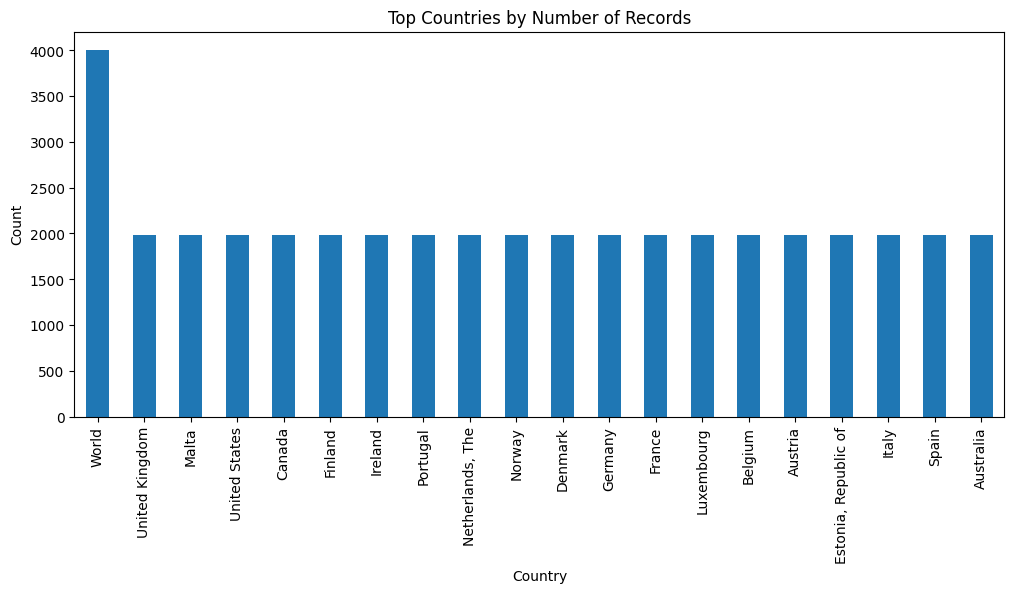

In [ ]:
df["country"].value_counts().head(20).plot(kind="bar", figsize=(12,5))

plt.title("Top Countries by Number of Records")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

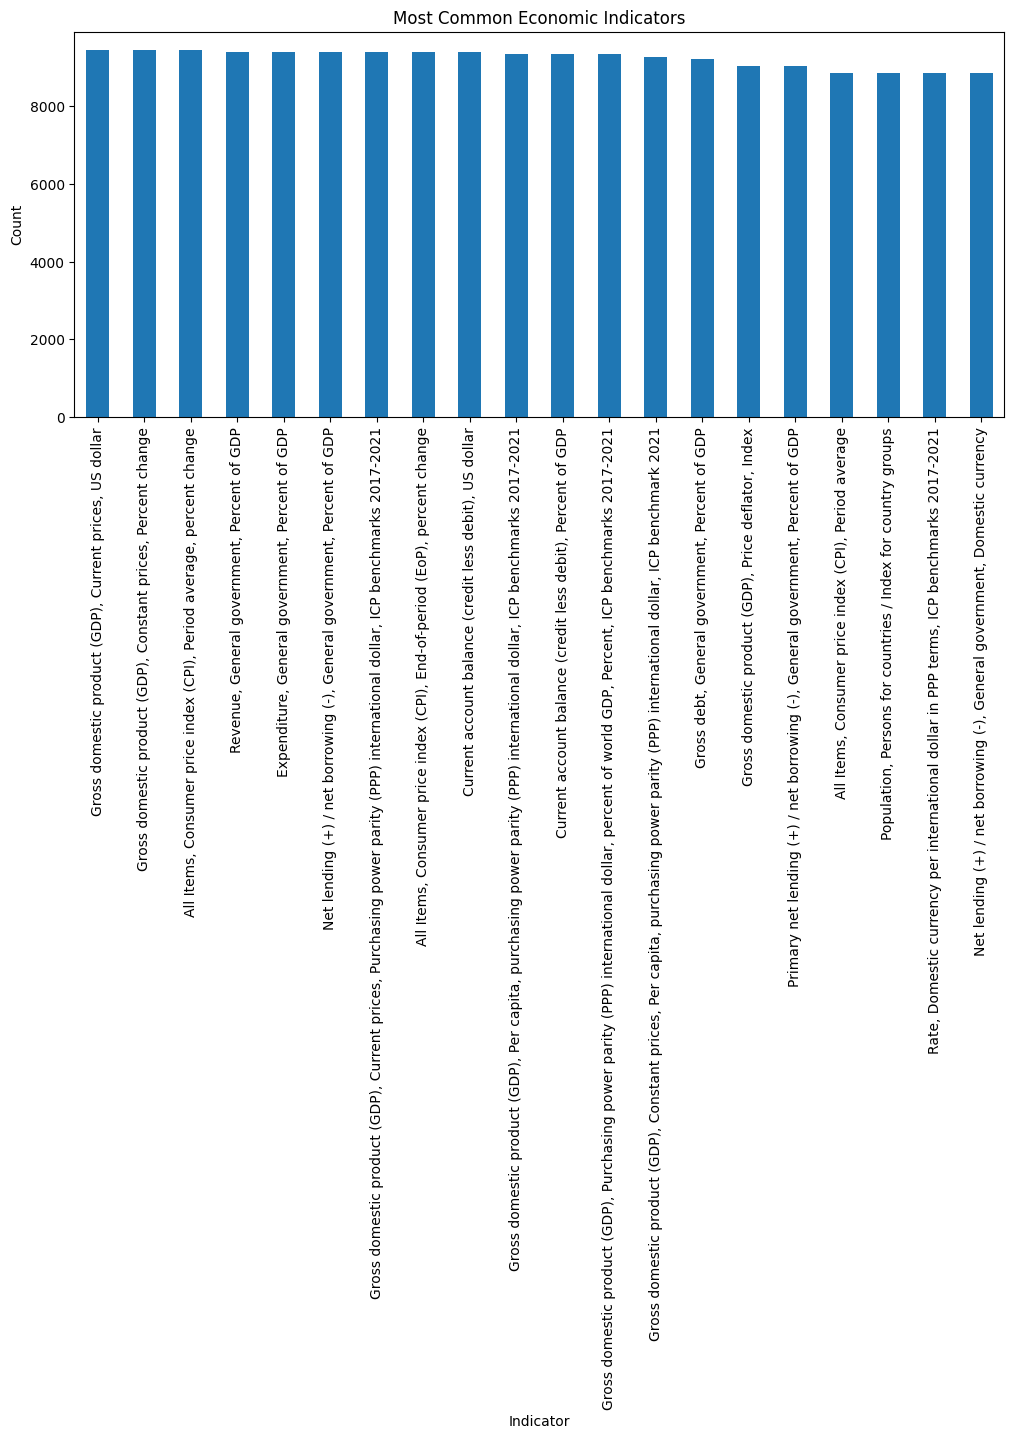

In [ ]:
df["indicator"].value_counts().head(20).plot(kind="bar", figsize=(12,5))

plt.title("Most Common Economic Indicators")
plt.xlabel("Indicator")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

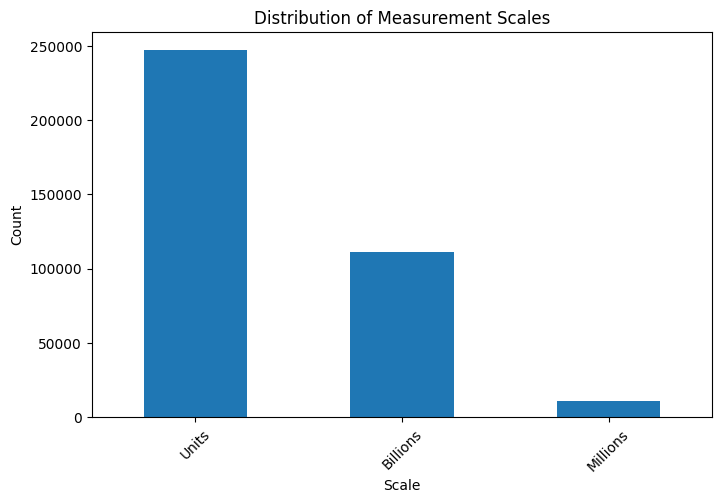

In [ ]:
df["scale"].value_counts().plot(kind="bar", figsize=(8,5))

plt.title("Distribution of Measurement Scales")
plt.xlabel("Scale")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

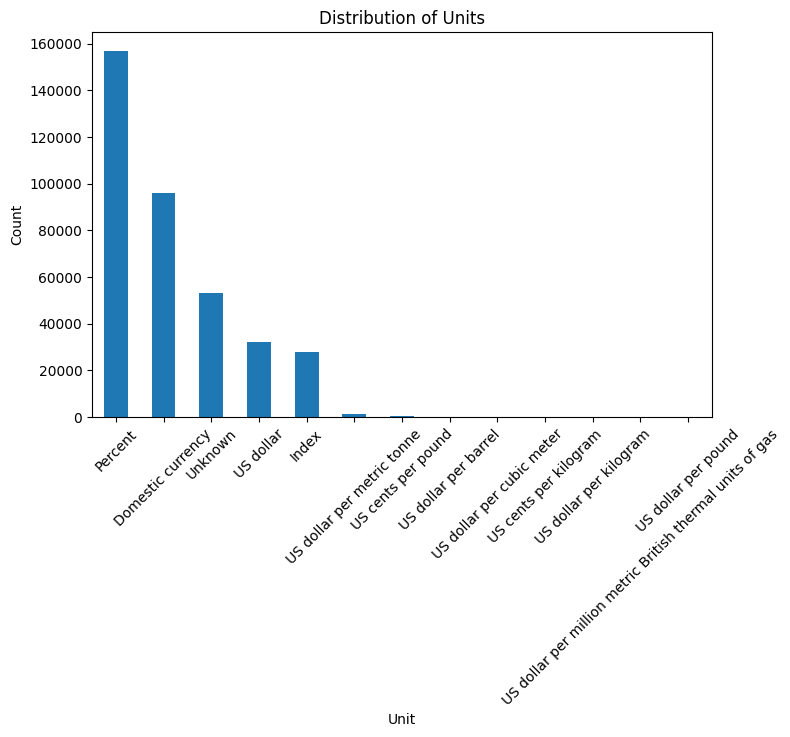

In [ ]:
df["unit"].value_counts().plot(kind="bar", figsize=(8,5))

plt.title("Distribution of Units")
plt.xlabel("Unit")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [ ]:
year_cols = ["Year"]

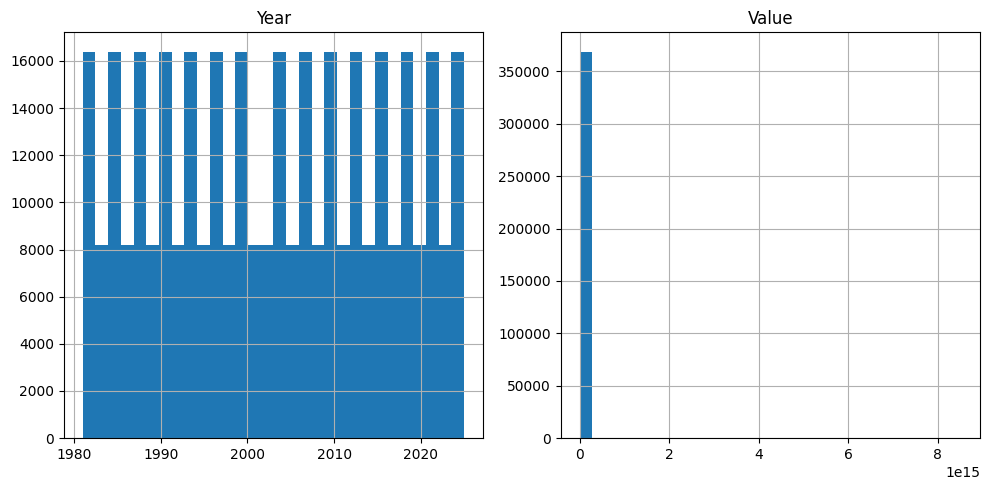

In [ ]:
df[["Year", "Value"]].hist(figsize=(10,5), bins=30)

plt.tight_layout()
plt.show()

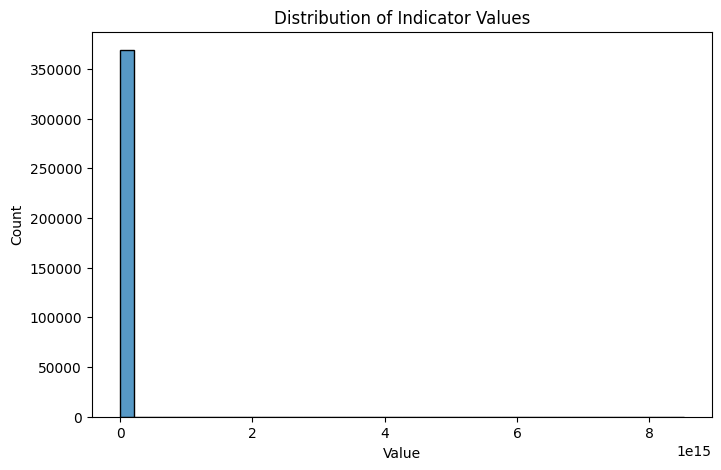

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["Value"], bins=40)

plt.title("Distribution of Indicator Values")
plt.show()

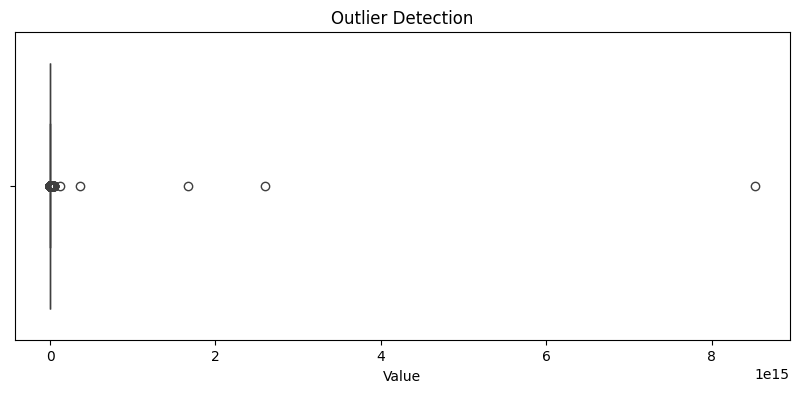

In [ ]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df["Value"])

plt.title("Outlier Detection")
plt.show()

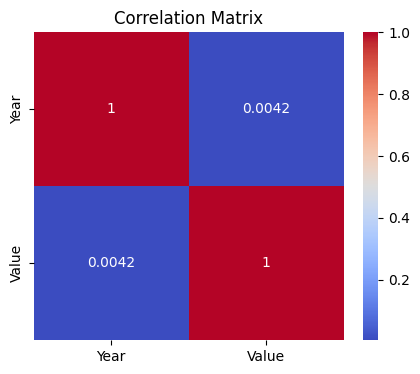

In [ ]:
corr = df[["Year","Value"]].corr()

plt.figure(figsize=(5,4))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

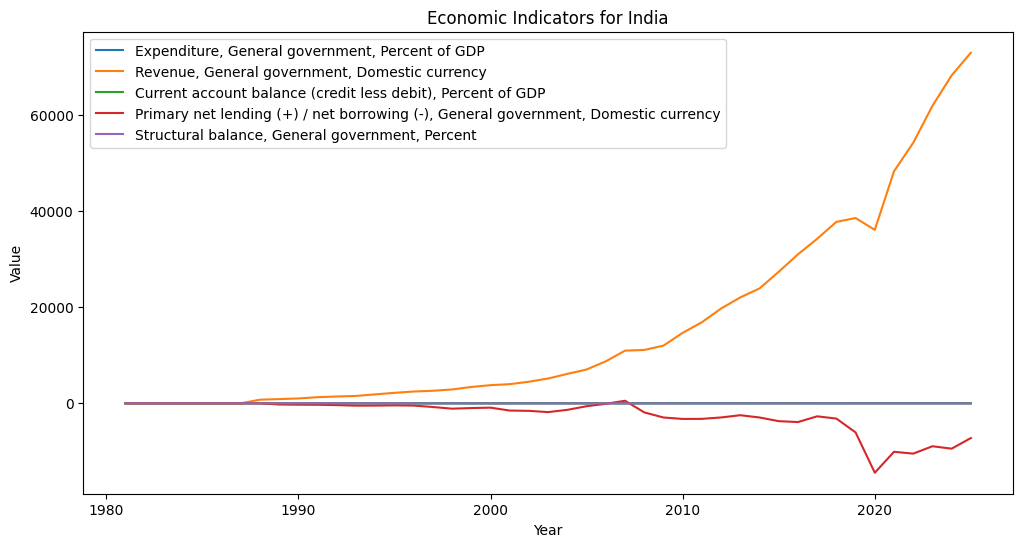

In [ ]:
country = "India"

sample = df[df["country"] == country]

plt.figure(figsize=(12,6))

for indicator in sample["indicator"].unique()[:5]:
    temp = sample[sample["indicator"] == indicator]
    plt.plot(temp["Year"], temp["Value"], label=indicator)

plt.title(f"Economic Indicators for {country}")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend()
plt.show()

In [ ]:
df = df.drop_duplicates()

df = df.dropna()

print(df.shape)

(368865, 7)


In [ ]:
df_ml = df.copy()

encoder = LabelEncoder()

categorical_cols = [
    "country",
    "series_code",
    "indicator",
    "scale",
    "unit"
]

for col in categorical_cols:
    df_ml[col] = encoder.fit_transform(df_ml[col])

In [ ]:
X = df_ml.drop("Value", axis=1)

y = df_ml["Value"]

print(X.shape)
print(y.shape)

(368865, 6)
(368865,)


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

print("Training :", X_train.shape)
print("Validation:", X_val.shape)
print("Testing :", X_test.shape)

Training : (258205, 6)
Validation: (55330, 6)
Testing : (55330, 6)


       Feature  Importance
1  series_code    0.396677
5         Year    0.304094
2    indicator    0.179071
4         unit    0.077492
0      country    0.026470
3        scale    0.016197


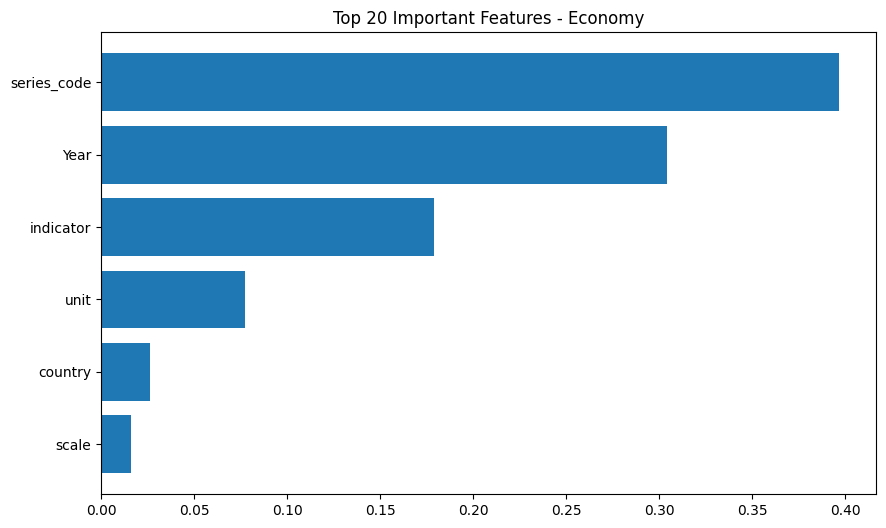

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(20))

plt.figure(figsize=(10,6))
plt.barh(
    importance['Feature'][:20],
    importance['Importance'][:20]
)
plt.gca().invert_yaxis()
plt.title("Top 20 Important Features - Economy")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Economy Dataset Performance")
print("---------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

Economy Dataset Performance
---------------------------
MAE : 44661986179.95867
MSE : 5.250896441843458e+25
RMSE: 7246306950332.326
R² Score: 0.5720747338101704
